In [1]:
# pip install ucimlrepo

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# data set source:
from ucimlrepo import fetch_ucirepo, list_available_datasets

In [3]:
heart_disease = fetch_ucirepo(id=45)

# access metadata
# print(heart_disease.metadata.uci_id)
# print(heart_disease.metadata.num_instances)
print(f"Summary:\n{heart_disease.metadata.additional_info.summary}\n")

print(f"Abstract:\n{heart_disease.metadata.abstract}")

Summary:
This database contains 76 attributes, but all published experiments refer to using a subset of 14 of them.  In particular, the Cleveland database is the only one that has been used by ML researchers to date.  The "goal" field refers to the presence of heart disease in the patient.  It is integer valued from 0 (no presence) to 4. Experiments with the Cleveland database have concentrated on simply attempting to distinguish presence (values 1,2,3,4) from absence (value 0).  
   
The names and social security numbers of the patients were recently removed from the database, replaced with dummy values.

One file has been "processed", that one containing the Cleveland database.  All four unprocessed files also exist in this directory.

To see Test Costs (donated by Peter Turney), please see the folder "Costs" 

Abstract:
4 databases: Cleveland, Hungary, Switzerland, and the VA Long Beach


In [4]:
# print(fr"Characteristics: {heart_disease.metadata.characteristics}")
print(fr"Num Rows: {heart_disease.metadata.num_instances}")
print(fr"Num Columns: {heart_disease.metadata.num_features}")
print(fr"Feature Types: {heart_disease.metadata.feature_types}")
print(fr"Target Column(s) Name: {heart_disease.metadata.target_col}")
print(fr"Index Columns Names: {heart_disease.metadata.index_col}")
print(fr"Has Missing Values: {heart_disease.metadata.has_missing_values}")
print(fr"Missing Value Symbol: {heart_disease.metadata.missing_value_symbol}")
print(fr"Data URL: {heart_disease.metadata.data_url}")

Num Rows: 303
Num Columns: 13
Feature Types: ['Categorical', 'Integer', 'Real']
Target Column(s) Name: ['num']
Index Columns Names: None
Has Missing Values: yes
Missing Value Symbol: None
Data URL: https://archive.ics.uci.edu/static/public/45/data.csv


In [5]:
# # print(heart_disease)
# print(type(heart_disease))

# print(type(heart_disease.data.features))

df = heart_disease.data.original
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')

In [6]:
df.shape

(303, 14)

## Understanding the Features

In [8]:
df_columns = df.columns.tolist() # converst df.columns to a usable list
# print(f"All Columns:\n{df_columns} \n")

feature_columns = df_columns.copy()
feature_columns.remove("num")
# print(f"Feature Columns:\n{feature_columns}\n")

target_column = df_columns[-1]
# print(f"Targe Column:\n{target_column}\n")

In [9]:
feature_explain_df = pd.read_csv("Features_List.csv")
feature_explain_df.head(13)

,Name,Role,Type,Units,Description,Missing Values
0,age,feature,integer,years,NaN,No
1,sex,feature,categorical,NaN,NaN,No
2,cp,feature,categorical,NaN,NaN,No
3,trestbps,feature,integer,mm Hg,resting blood pressure (on admission to the ho...,No
4,chol,feature,integer,mg/dl,serum cholestoral,No
5,fbs,feature,categorical,NaN,fasting blood sugar > 120 mg/dl,No
6,restecg,feature,categorical,NaN,NaN,No
7,thalach,feature,integer,NaN,maximum heart rate achieved,No
8,exang,feature,categorical,NaN,exercise induced angina,No
9,oldpeak,feature,integer,NaN,ST depression induced by exercise relative to ...,No


The creators of the dataset have already converted the categorical features into numeric values. I will need to find what each numeric value represnts.

In [54]:
# get the ranges of each column
print("Value Ranges")
for col in df_columns:
    print(f"\t{col}: {df[col].min()} - {df[col].max()}")

# store categorical columns
categorical_columns = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"] 
# I added ca because it's integers are inline with how the categorical values are organized

for col in categorical_columns:
    print(df[col].value_counts())

continuous_columns = feature_columns.copy()
continuous_columns = [x for x in continuous_columns if x not in categorical_columns]
print(continuous_columns)

Value Ranges
	age: 29 - 77
	sex: 0 - 1
	cp: 1 - 4
	trestbps: 94 - 200
	chol: 126 - 564
	fbs: 0 - 1
	restecg: 0 - 2
	thalach: 71 - 202
	exang: 0 - 1
	oldpeak: 0.0 - 6.2
	slope: 1 - 3
	ca: 0.0 - 3.0
	thal: 3.0 - 7.0
	num: 0 - 4
sex
1    206
0     97
Name: count, dtype: int64
cp
4    144
3     86
2     50
1     23
Name: count, dtype: int64
fbs
0    258
1     45
Name: count, dtype: int64
restecg
0    151
2    148
1      4
Name: count, dtype: int64
exang
0    204
1     99
Name: count, dtype: int64
slope
1    142
2    140
3     21
Name: count, dtype: int64
ca
0.0    176
1.0     65
2.0     38
3.0     20
Name: count, dtype: int64
thal
3.0    166
7.0    117
6.0     18
Name: count, dtype: int64
['age', 'trestbps', 'chol', 'thalach', 'oldpeak']


I am mildly concerned that this data set is skewed towards men. I am concerned with the difference in values within all the categorical values. I need to check for corelation.

### Attribute documentation

- age: age in years
- sex: sex (1 = male; 0 = female)
- painloc: chest pain location (1 = substernal; 0 = otherwise)
- cp: chest pain type
  - Value 1: typical angina
  - Value 2: atypical angina
  - Value 3: non-anginal pain
  - Value 4: asymptomatic
- trestbps: resting blood pressure (in mm Hg on admission to the hospital)
- htn
- chol: serum cholestoral in mg/dl
- restecg: resting electrocardiographic results
        -- Value 0: normal
        -- Value 1: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV)
        -- Value 2: showing probable or definite left ventricular hypertrophy by Estes' criteria
- fbs: (fasting blood sugar > 120 mg/dl) (1 = true; 0 = false)
- thalach: maximum heart rate achieved
- exang: exercise induced angina (1 = yes; 0 = no)
- oldpeak = ST depression induced by exercise relative to rest
- slope: the slope of the peak exercise ST segment
  - Value 1: upsloping
  - Value 2: flat
  - Value 3: downsloping
- ca: number of major vessels (0-3) colored by flourosopy
- thal: 3 = normal; 6 = fixed defect; 7 = reversable defect
- num: diagnosis of heart disease (angiographic disease status)
  - Value 0: < 50% diameter narrowing
  - Value 1: > 50% diameter narrowing
  - (in any major vessel: attributes 59 through 68 are vessels)|

## Finding Null values

There are 4 missing values in ca (blood vessels), and 2 missing values in thal. Missing values are NaN

In [15]:
# df.duplicated().sum() # number of duplicate rows
# df.isnull().sum() # Missing Values per Column

In [16]:
rows_with_nulls = df[df.isnull().any(axis=1)]

rows_with_nulls.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
87,53,0,3,128,216,0,2,115,0,0.0,1,0.0,NaN,0
166,52,1,3,138,223,0,0,169,0,0.0,1,NaN,3.0,0
192,43,1,4,132,247,1,2,143,1,0.1,2,NaN,7.0,1
266,52,1,4,128,204,1,0,156,1,1.0,2,0.0,NaN,2
287,58,1,2,125,220,0,0,144,0,0.4,2,NaN,7.0,0
302,38,1,3,138,175,0,0,173,0,0.0,1,NaN,3.0,0


None of the rows have multiple missing values, and it is only 6 out of 303 (~2%) of the rows have missing values.   
I still have to check for outliers, but I believe I will either be able to drop the rows or fill them in with the mode.

## Finding Outliers

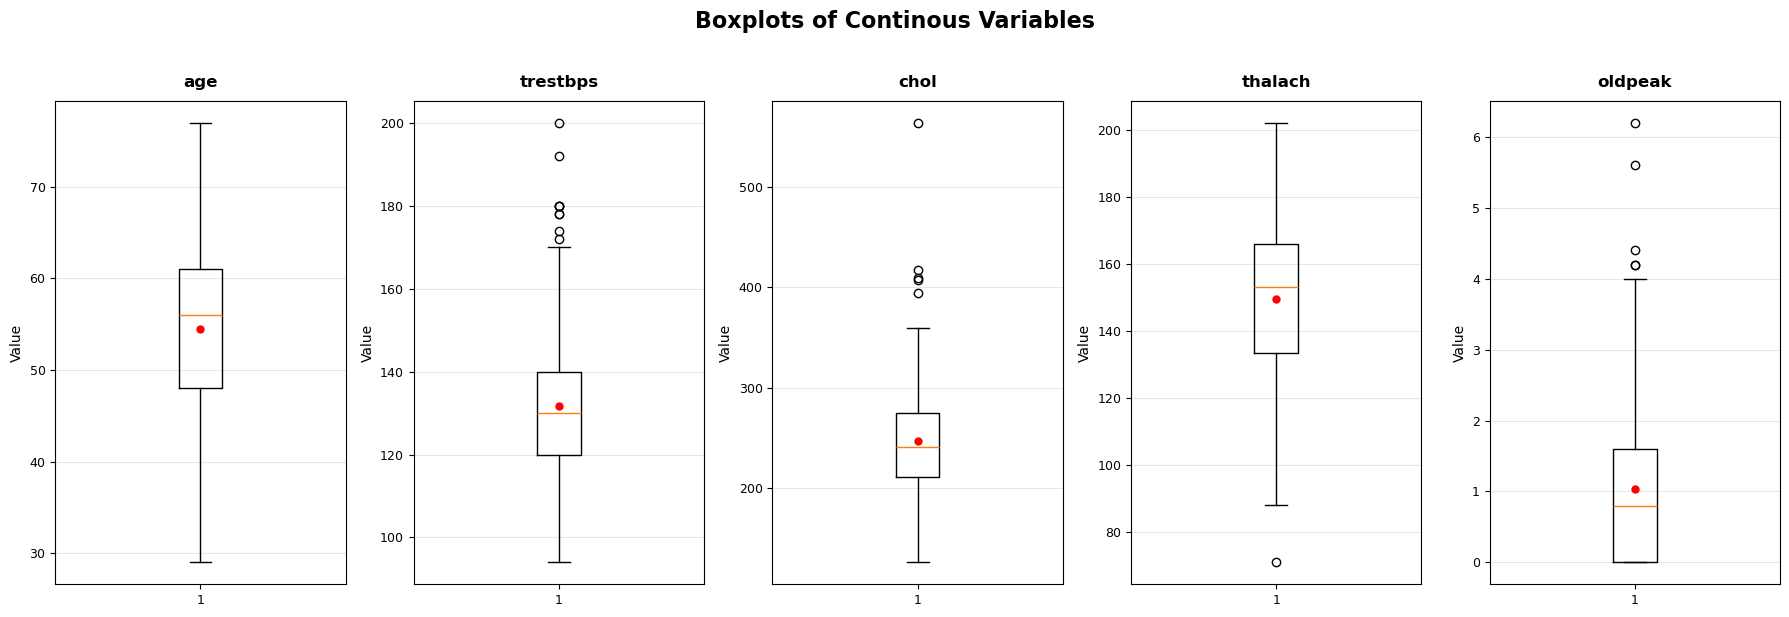

In [19]:
fig, axes = plt.subplots(1, len(continuous_columns), figsize=(18, 6))

for i, col in enumerate(continuous_columns):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(f'{col}', fontsize=12, fontweight='bold', pad=10)
    axes[i].set_ylabel('Value', fontsize=10)
    axes[i].grid(True, alpha=0.3, axis='y')
    axes[i].tick_params(axis='both', labelsize=9)
    
    #mean as a red point
    mean_val = df[col].mean()
    axes[i].plot(1, mean_val, 'ro', markersize=5)

plt.suptitle('Boxplots of Continous Variables', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Initial Outlier Assessment
- Trestbps: (trestbps: resting blood pressure (in mm Hg on admission to the hospital))
- Chol (Cholesterol)
- Thalach
- oldpeak
Theses each have outliers with trestbps and cholesterol seeming to have the most outliers.   
My initial guess is that all of the outliers correlate to the presence of heat disease, but I will have to test correlation.

In [21]:
for col in continuous_columns:
    col_values = df[col]
    percentile_25 = col_values.quantile(0.25) # calcs 25th Percentile
    percentile_75 = col_values.quantile(0.75) # calcs 75th Percentile

    iqr = percentile_75 - percentile_25

    # calculate the upper and lower thresholds
    upper = percentile_75 + 1.5 * iqr
    lower = percentile_25 - 1.5 * iqr # 1.5 is chosen out of convention

    # identify outliers
    lower_outliers = df[col_values < lower]
    upper_outliers = df[col_values > upper]

    print("")
    print(f"{col}: Upper Threshold ({round(upper,5)}), Lower Threshold ({round(lower,5)})")

    
    print(f"Is Lower Outliers Empty: {lower_outliers.empty}")
    print(f"Is Upper Outliers Empty: {upper_outliers.empty}")

    # display the outliers if present
    for row in lower_outliers.itertuples():
        print(row)

    for row in upper_outliers.itertuples():
        print(row)


age: Upper Threshold (80.5), Lower Threshold (28.5)
Is Lower Outliers Empty: True
Is Upper Outliers Empty: True

trestbps: Upper Threshold (170.0), Lower Threshold (90.0)
Is Lower Outliers Empty: True
Is Upper Outliers Empty: False
Pandas(Index=14, age=52, sex=1, cp=3, trestbps=172, chol=199, fbs=1, restecg=0, thalach=162, exang=0, oldpeak=0.5, slope=1, ca=0.0, thal=7.0, num=0)
Pandas(Index=83, age=68, sex=1, cp=3, trestbps=180, chol=274, fbs=1, restecg=2, thalach=150, exang=1, oldpeak=1.6, slope=2, ca=0.0, thal=7.0, num=3)
Pandas(Index=126, age=56, sex=0, cp=4, trestbps=200, chol=288, fbs=1, restecg=2, thalach=133, exang=1, oldpeak=4.0, slope=3, ca=2.0, thal=7.0, num=3)
Pandas(Index=172, age=59, sex=0, cp=4, trestbps=174, chol=249, fbs=0, restecg=0, thalach=143, exang=1, oldpeak=0.0, slope=2, ca=0.0, thal=3.0, num=1)
Pandas(Index=183, age=59, sex=1, cp=1, trestbps=178, chol=270, fbs=0, restecg=2, thalach=145, exang=0, oldpeak=4.2, slope=3, ca=0.0, thal=7.0, num=0)
Pandas(Index=188, a

My guess that all outliers have heart diesease is incorrect

## Initial Correlation Assessment

In [24]:
temp_df = df.copy()

# Replace values
temp_df['num'] = temp_df['num'].replace([2,3,4],1)

temp_df = temp_df.rename(columns={"num":"disease_present"})


temp_df.head

<bound method NDFrame.head of      age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0     63    1   1       145   233    1        2      150      0      2.3   
1     67    1   4       160   286    0        2      108      1      1.5   
2     67    1   4       120   229    0        2      129      1      2.6   
3     37    1   3       130   250    0        0      187      0      3.5   
4     41    0   2       130   204    0        2      172      0      1.4   
..   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
298   45    1   1       110   264    0        0      132      0      1.2   
299   68    1   4       144   193    1        0      141      0      3.4   
300   57    1   4       130   131    0        0      115      1      1.2   
301   57    0   2       130   236    0        2      174      0      0.0   
302   38    1   3       138   175    0        0      173      0      0.0   

     slope   ca  thal  disease_present  
0        3  0.0 

Box plots for continous values

In [49]:

# fig, axes = plt.subplots(2, 3, figsize=(15, 10))
# axes = axes.flatten()

# for i, col in enumerate(continuous_columns):
#     sns.boxplot(x=temp_df['disease_present'], y=temp_df[col], ax=axes[i])
#     axes[i].set_title(f'{col} by Target', fontsize=10)
#     axes[i].set_xlabel('Target (0=No, 1=Yes)')
    
# # Hide unused subplots
# for j in range(i+1, len(axes)):
#     axes[j].set_visible(False)

# plt.tight_layout()
# plt.show()

Typically, high cholesterol is considered an risk factor in Heart Disease, but here the higher cholesterol tends to have less disease present. I think this may be due to the dataset using serum cholesterol which takes both LDL ("bad") and HDL ("good"). But the dataset does not make a distinction between them. For this reason I think it may be beneficial to remove cholesterol from the ML testing.

Histograms for continous values

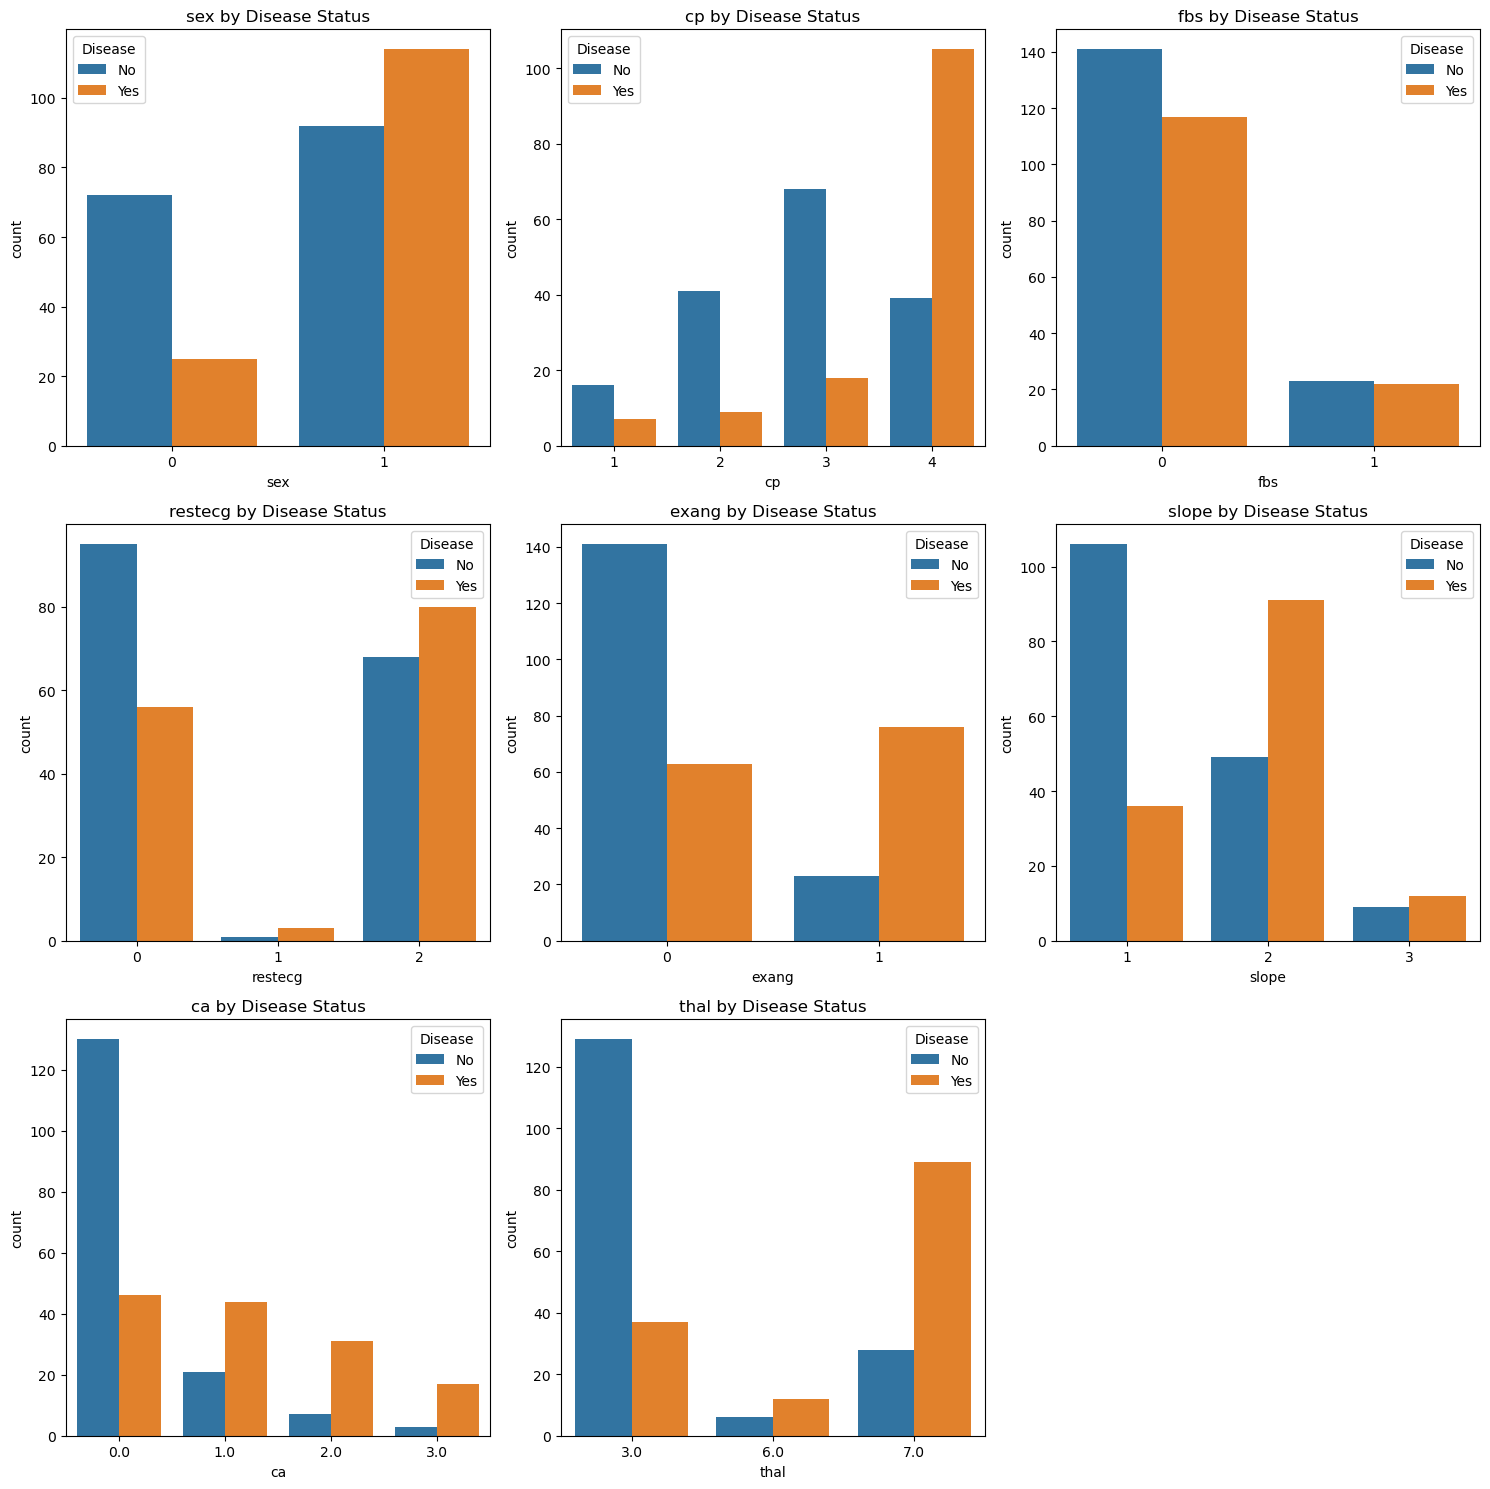

In [68]:
# Calculate grid based on your categorical columns
n_cols = 3
n_rows = (len(categorical_columns) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.flatten()

for i, col in enumerate(categorical_columns):
    sns.countplot(data=temp_df, x=col, hue='disease_present', ax=axes[i])
    axes[i].set_title(f'{col} by Disease Status')
    axes[i].legend(title='Disease', labels=['No', 'Yes'])

# Hide unused axes
for j in range(len(categorical_columns), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()